# Semantic abstraction graphicalizer

Thin experiment notebook: configure the run, invoke the package, and visualize the resulting graph, sample a connected subgraph, and narrate it.

In [27]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import textwrap

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'assets').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'assets').exists():
    raise FileNotFoundError('Could not locate the repository assets directory.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graphicalizer import (
    ExtractionDensityConfig,
    Graphicalizer,
    GraphicalizerConfig,
    NodeContextConfig,
    SubgraphNarrator,
    SubgraphNarrativeConfig,
    SubgraphNarrativePrompt,
    sample_random_connected_subgraph,
    graph_to_dot,
    load_ontology,
    load_text,
    render_graph,
    validate_ontology_labeled_graph,
)
from IPython.display import SVG, display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configure and run

In [28]:
ASSETS_ROOT = PROJECT_ROOT / 'assets'
PUBMED_ABSTRACT_INDEX = 3  # zero-based: 0 selects the first abstract
PUBMED_ABSTRACT_PATHS = sorted((ASSETS_ROOT / 'abstracts' / 'pubmed').glob('*.txt'))
if not PUBMED_ABSTRACT_PATHS:
    raise FileNotFoundError('No PubMed abstracts found.')
if not 0 <= PUBMED_ABSTRACT_INDEX < len(PUBMED_ABSTRACT_PATHS):
    raise IndexError(
        f'PUBMED_ABSTRACT_INDEX must be between 0 and {len(PUBMED_ABSTRACT_PATHS) - 1}.'
    )
ABSTRACT_PATH = PUBMED_ABSTRACT_PATHS[PUBMED_ABSTRACT_INDEX]
ASSEMBLED_ONTOLOGY_PATH = ASSETS_ROOT / 'ontologies' / 'entity_ontology_microbiology_assembled.yaml'
ONTOLOGY_PATH = (
    ASSEMBLED_ONTOLOGY_PATH
    if ASSEMBLED_ONTOLOGY_PATH.exists()
    else ASSETS_ROOT / 'ontologies' / 'entity_ontology_microbiology.yaml'
)
PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'graphicalizer_prompt_template.yaml'
PROMPT_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'ontology-aware-graphicalizer-0.4.0.yaml'
GRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_ontology_graph.svg'
LLM_PROVIDER = 'openai'  # choose 'openai' or 'ollama'
LLM_MODEL = 'gpt-4o-mini' if LLM_PROVIDER == 'openai' else 'gemma4:12b-mlx' # 'gpt-4o-mini' 'gpt-5-nano'
LLM_OPTIONS = (
    {'max_output_tokens': 16384}
    if LLM_PROVIDER == 'openai'
    else {'num_ctx': 32768, 'num_predict': -1}
)
NARRATIVE_COLUMNS = 80

abstract_text = load_text(ABSTRACT_PATH)
print(textwrap.fill(abstract_text, width=NARRATIVE_COLUMNS))

ontology = load_ontology(ONTOLOGY_PATH)
ENTITY_EFFORT = 0.2
RELATION_EFFORT = 1.5
density = ExtractionDensityConfig(
    entities_per_word=ENTITY_EFFORT,
    relations_per_entity=RELATION_EFFORT,
)
context = NodeContextConfig(
    max_sentences=3,
    max_evidence_items=2,
    include_evidence=True,
    include_uncertainty=True,
)
config = GraphicalizerConfig(
    provider=LLM_PROVIDER,
    model=LLM_MODEL,
    extraction_density=density,
    node_context=context,
    prompt_template_path=PROMPT_PATH,
    prompt_snapshot_path=PROMPT_SNAPSHOT_PATH,
    disconnected_policy='largest_component',
    context_policy='all_nodes',
    casting_retries=2,
)

graphicalizer = Graphicalizer.from_provider(ontology, config, options=LLM_OPTIONS)
result = graphicalizer.run(abstract_text)

Title: Nipah virus: pathogenesis, genome, diagnosis, and treatment. PMID:
40593310 Journal: Applied microbiology and biotechnology Publication date:
2025Jul01 DOI: 10.1007/s00253-025-13474-6 Authors: Rishav Madhukalya, Urvashi
Yadav, Hilal Ahmad Parray, Nisha Raj, Santhik Subhasingh Lupitha, Vivek Kumar,
Anjali Saroj, Vidushi Agarwal, Dilip Kumar, Supratik Das, Rajesh Kumar
Abstract: The highly infectious Nipah virus (NiV) is classified under the
Paramyxoviridae family and is categorized under the genus Henipavirus. NiV
spreads to humans through zoonotic transmission from reservoir host bats and
other intermediate hosts. It is highly contagious and has a high case fatality
rate (CFR) of ~ 40-80%. Only sporadic outbreaks have been reported so far, but
like SARS-CoV2, NiV has a high pandemic potential and has been put on the World
Health Organization (WHO) priority pathogen list. Currently, no clinically
approved antivirals, immunotherapy, or vaccines are available to tackle NiV
infectio

In [29]:
print('Model:', config.model)
print('Source SHA-256:', result.run_metadata['source_sha256'])
print('Raw validation:', result.raw_validation.to_dict())
print('Normalized validation:', result.normalized_validation.to_dict())
print('Normalization report:', result.normalization_report)
print('Final validation:', result.final_validation.to_dict())
print('Entities:', len(result.normalized_extraction.entities))
print('Relations:', len(result.ontology_casting.relations))
print('Node contexts:', len(result.node_contexts))

Model: gpt-4o-mini
Source SHA-256: 582a610a4ac4115dd0afcf813b8474efb8b98dcec285f90343b10c1e63b69a20
Raw validation: {'valid': False, 'connected': False, 'sparse': True, 'node_count': 11, 'edge_count': 9, 'density': 0.16363636363636364, 'max_neighbor_count': 8, 'hub_nodes': ('e1',), 'issues': ('graph is disconnected', 'graph contains 1 hub node(s): e1'), 'density_ok': True, 'hubs_ok': False}
Normalized validation: {'valid': False, 'connected': True, 'sparse': True, 'node_count': 9, 'edge_count': 8, 'density': 0.2222222222222222, 'max_neighbor_count': 8, 'hub_nodes': ('e1',), 'issues': ('graph contains 1 hub node(s): e1',), 'density_ok': True, 'hubs_ok': False}
Normalization report: {'policy': 'largest_component', 'component_count': 2, 'retained_entity_ids': ('e1', 'e2', 'e3', 'e4', 'e7', 'e8', 'e9', 'e10', 'e11'), 'discarded_entity_ids': ('e5', 'e6'), 'retained_relation_ids': ('r1', 'r2', 'r3', 'r5', 'r6', 'r7', 'r8', 'r9'), 'discarded_relation_ids': ('r4',)}
Final validation: {'valid':

## Visualize the typed graph

digraph "NipahVirusZoonoticGraph" {
  rankdir=LR;
  "e1" [label="virus\nNipah virus", shape=box];
  "e10" [label="clinical_entity\ndiagnostics", shape=box];
  "e11" [label="intervention\ntherapeutics", shape=box];
  "e2" [label="virus_family\nParamyxoviridae", shape=box];
  "e3" [label="virus\nHenipavirus", shape=box];
  "e4" [label="reservoir_host\nbats", shape=box];
  "e7" [label="epidemiological_measure\ncase fatality rate (CFR)", shape=box];
  "e8" [label="biological_host\nWorld Health Organization (WHO)", shape=box];
  "e9" [label="epidemiological_measure\npandemic potential", shape=box];
  "e1" -> "e2" [color="#555555", label="subtype_of"];
  "e1" -> "e3" [color="#555555", label="subtype_of"];
  "e1" -> "e4" [color="#555555", label="spills_over_from"];
  "e1" -> "e7" [color="#555555", label="associated_with"];
  "e1" -> "e9" [color="#555555", label="associated_with"];
  "e10" -> "e1" [color="#555555", label="prevents"];
  "e11" -> "e1" [color="#555555", label="supports"];
  "e8" 

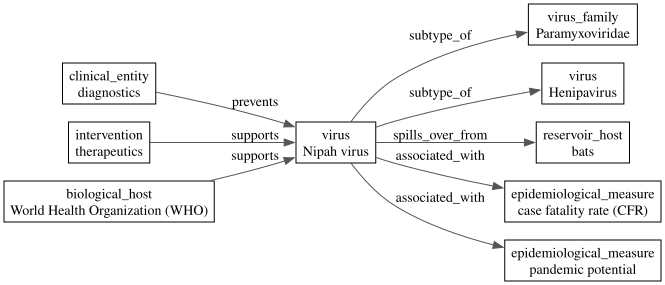

In [30]:
validate_ontology_labeled_graph(result.typed_graph)
dot_text = graph_to_dot(
    result.typed_graph,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
print(dot_text)
render_graph(
    result.typed_graph,
    GRAPH_OUTPUT_PATH,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(GRAPH_OUTPUT_PATH)))

## Sample and narrate a connected subgraph

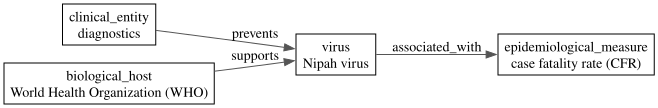

In [31]:
SUBGRAPH_NODE_COUNT = 4
SUBGRAPH_SEED = None
NARRATIVE_WORDS = 100
SUBGRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_random_subgraph.svg'
NARRATIVE_PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'subgraph_narrative_prompt_template.yaml'
NARRATIVE_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'subgraph-narrator-0.1.0.yaml'

sampled_subgraph = sample_random_connected_subgraph(
    result.typed_graph,
    num_nodes=SUBGRAPH_NODE_COUNT,
    seed=SUBGRAPH_SEED,
)
validate_ontology_labeled_graph(sampled_subgraph)
render_graph(
    sampled_subgraph,
    SUBGRAPH_OUTPUT_PATH,
    graph_name='NipahRandomSubgraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(SUBGRAPH_OUTPUT_PATH)))

In [32]:

narrator_prompt = SubgraphNarrativePrompt.from_yaml_file(NARRATIVE_PROMPT_PATH)
narrator = SubgraphNarrator.from_graphicalizer(
    graphicalizer,
    prompt=narrator_prompt,
    prompt_snapshot_path=NARRATIVE_SNAPSHOT_PATH,
)
narrative = narrator.narrate(
    sampled_subgraph,
    SubgraphNarrativeConfig(target_words=NARRATIVE_WORDS),
)
print(textwrap.fill(narrative.narrative, width=NARRATIVE_COLUMNS))
print('Requested words:', narrative.requested_words)
print('Actual words:', narrative.actual_words)
if narrative.uncertainty:
    print('Uncertainty:', narrative.uncertainty)


Nipah virus (NiV) is a highly infectious pathogen classified under the
Paramyxoviridae family, particularly within the genus Henipavirus. It poses a
significant public health risk, with a case fatality rate (CFR) ranging from 40%
to 80%. This alarming CFR highlights the severe consequences of outbreaks linked
to NiV. Due to its infectious nature and potential for transmission from bats to
humans, the World Health Organization (WHO) has prioritized this virus on its
list of critical pathogens. Effective diagnostics are crucial for identifying
cases, which is essential for controlling potential outbreaks and mitigating
risks to human populations.
Requested words: 100
Actual words: 96


## Inspect node contexts

In [33]:
for node_context in result.node_contexts:
    print(f'\n[{node_context.entity_id}] {textwrap.fill(node_context.summary, width=NARRATIVE_COLUMNS)}')
    for evidence in node_context.evidence:
        print(f'  evidence: {textwrap.fill(evidence, width=NARRATIVE_COLUMNS)}')
    if node_context.uncertainty:
        print(f'  uncertainty: {textwrap.fill(node_context.uncertainty, width=NARRATIVE_COLUMNS)}')


[e1] Nipah virus (NiV) is a highly infectious virus classified under the
Paramyxoviridae family and the genus Henipavirus, known for zoonotic
transmission from bats to humans, with a case fatality rate of 40-80%. It has
been prioritized by the WHO due to its pandemic potential and lack of approved
treatments.
  evidence: ...has been put on the World Health Organization (WHO) priority pathogen list.
  evidence: It is highly contagious and has a high case fatality rate (CFR) of ~ 40-80%.

[e2] Paramyxoviridae is the virus family to which Nipah virus belongs, indicating its
classification in the broader context of viral taxonomy.
  evidence: Nipah virus (NiV) is classified under the Paramyxoviridae family.

[e3] Henipavirus is the genus classification of Nipah virus, representing its
specific taxonomic grouping within the Paramyxoviridae family.
  evidence: Nipah virus (NiV) is categorized under the genus Henipavirus.

[e4] Bats are the primary reservoir hosts for Nipah virus, facilitati